In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings("ignore")

# <---- Date Set will Load

In [2]:
    df=pd.read_csv("insurance.csv")

# 2-Understsnd the data 

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
df.shape

(1338, 7)

In [6]:
df.columns 

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


# 3-Find the missing value 

In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

# 4-columns renameing

In [10]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [11]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [12]:
df['age'].value_counts()

age
18    69
19    68
46    29
52    29
48    29
20    29
45    29
47    29
51    29
50    29
28    28
25    28
23    28
27    28
22    28
26    28
24    28
21    28
53    28
54    28
49    28
31    27
30    27
41    27
40    27
43    27
44    27
29    27
42    27
33    26
32    26
56    26
34    26
55    26
57    26
37    25
59    25
35    25
38    25
36    25
58    25
39    25
60    23
62    23
63    23
61    23
64    22
Name: count, dtype: int64

In [13]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [14]:
# change the smoker row name , yes=1, no=0,
df['smoker']=df['smoker'].replace({
    "yes":"1",
    "no":"0" 
})

In [15]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [16]:
# remove the 
df['charges'] = df['charges'].round(2)


# 5-cat_vs_num

In [17]:
num_col=df.select_dtypes(include='number').columns
num_col

Index(['age', 'bmi', 'children', 'charges'], dtype='str')

In [18]:
cat_col=df.select_dtypes(include="object").columns
cat_col

Index(['sex', 'smoker', 'region'], dtype='str')

In [19]:
print(len(num_col))
print(len(cat_col))

4
3


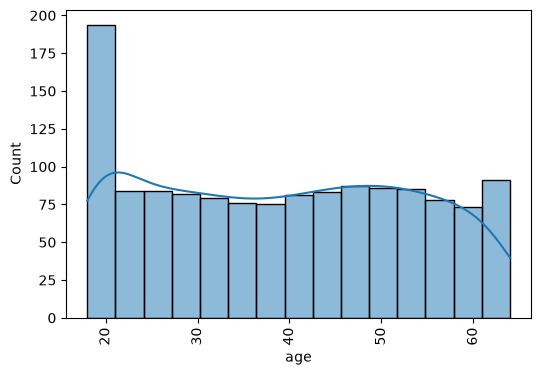

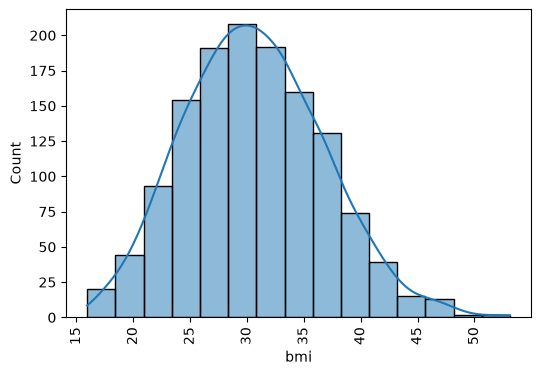

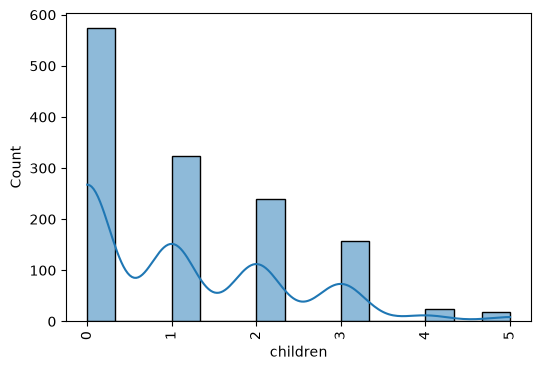

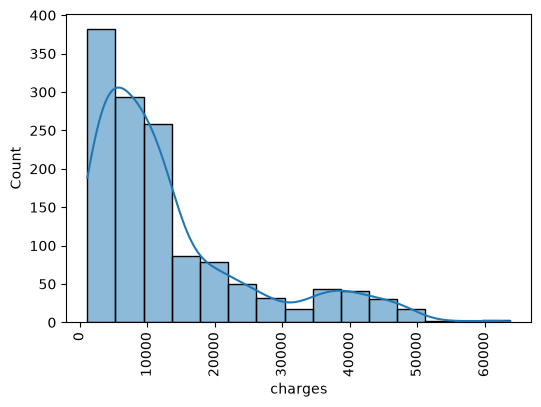

In [20]:
# check the distributions

for i in num_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[i],kde=True,bins=15)
    plt.xticks(rotation=90)
    plt.show()

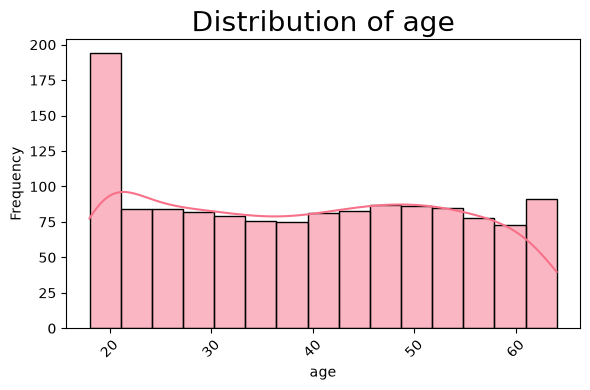

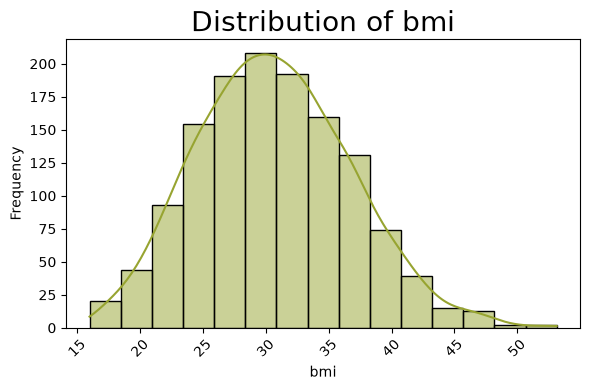

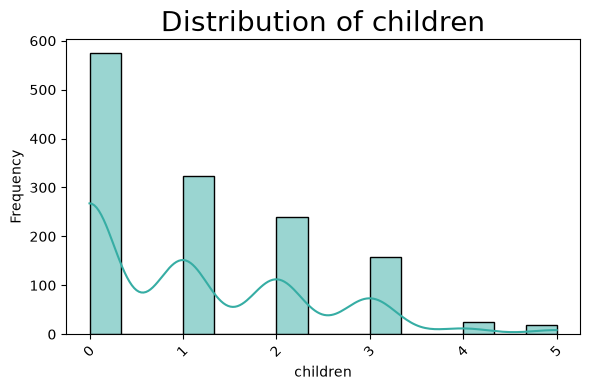

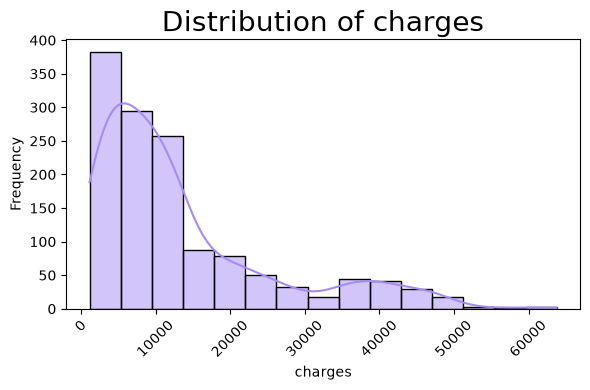

In [21]:

colors = sns.color_palette("husl", len(num_col))

for i, col in enumerate(num_col):
    plt.figure(figsize=(6, 4))
    
    sns.histplot(
        df[col],
        kde=True,
        bins=15,
        color=colors[i],
        edgecolor='black'
    )
    
    plt.title(f'Distribution of {col}', fontsize=20)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

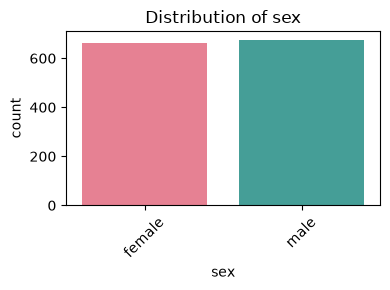

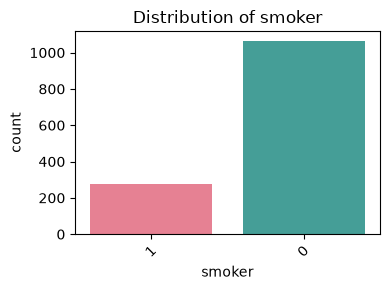

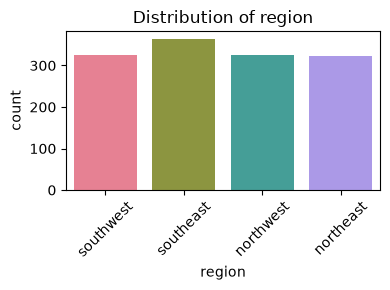

In [22]:
# cat_col are representing 
for col in cat_col:
    plt.figure(figsize=(4, 3))
    
    sns.countplot(
        data=df,
        x=col,
        hue=col,
        palette="husl",
        legend=False
    )
    
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# messure the columns

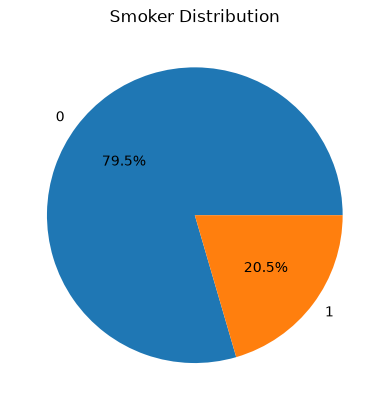

In [23]:
counts = df['smoker'].value_counts()

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%'
)

plt.title('Smoker Distribution')
plt.show()


<Axes: xlabel='children', ylabel='count'>

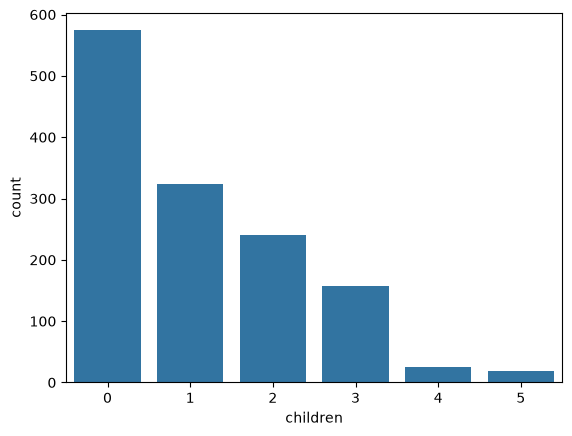

In [24]:
sns.countplot(x=df['children'])

In [25]:
df['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

<Axes: >

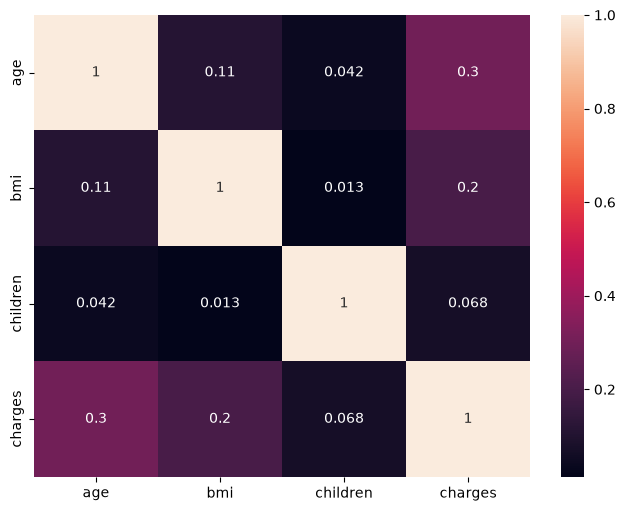

In [26]:
# heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# data cleaning & proccessing

In [27]:
# copy the df 
df_clean=df.copy()

In [28]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,1,southwest,16884.92
1,18,male,33.770,1,0,southeast,1725.55
2,28,male,33.000,3,0,southeast,4449.46
3,33,male,22.705,0,0,northwest,21984.47
4,32,male,28.880,0,0,northwest,3866.86


In [29]:
df_clean.drop_duplicates(inplace=True)

In [30]:
df_clean.shape 

(1337, 7)

In [31]:
df_clean.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

# Encoding labeled data

In [32]:
# in this data will be change
#     "southeast ":"0",
#     "southwest":"1",
#     "northwest":"2",
#     "northeast":"3"

df_clean['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [33]:
df_clean['region'] = df_clean['region'].replace({
    0: 'southeast',
    1: 'southwest',
    2: 'northwest',
    3: 'northeast'
})


In [34]:
df_clean['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [35]:
# and after replace the numbers in male = 0, female =1
df_clean['sex']=df_clean['sex'].replace({
    "male":"0",
    "female":"1"
},inplace=True)

In [36]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92
1,18,0,33.770,1,0,southeast,1725.55
2,28,0,33.000,3,0,southeast,4449.46
3,33,0,22.705,0,0,northwest,21984.47
4,32,0,28.880,0,0,northwest,3866.86


In [37]:
df_clean.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [38]:
# df_clean['sex']=df_clean['sex'].astype(int)
# df_clean['smoker']=df_clean['smoker'].astype(int)
# df_clean['region']=df_clean['region'].astype(int)

In [39]:
# bmi sort the value 
df_clean['bmi']=df_clean['bmi'].round(2)

In [40]:
df_clean.rename(columns={
    "sex":"is_Gender",
    "smoker":"is_smoker"
},inplace=True)

In [41]:
# change the rigions columns
df_clean=pd.get_dummies(df_clean, columns=['region'],drop_first=True)

In [42]:
df_clean.head()

,age,is_Gender,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.90,0,1,16884.92,False,False,True
1,18,0,33.77,1,0,1725.55,False,True,False
2,28,0,33.00,3,0,4449.46,False,True,False
3,33,0,22.70,0,0,21984.47,True,False,False
4,32,0,28.88,0,0,3866.86,True,False,False


In [43]:
# change the data type 
region_cols = ['region_northwest', 'region_southeast', 'region_southwest']

df_clean[region_cols] = df_clean[region_cols].astype(int)


In [44]:
# There wil be all change the datatype
df_clean=df_clean.astype(int)

# feature engineering and extraction

<Axes: xlabel='bmi', ylabel='Count'>

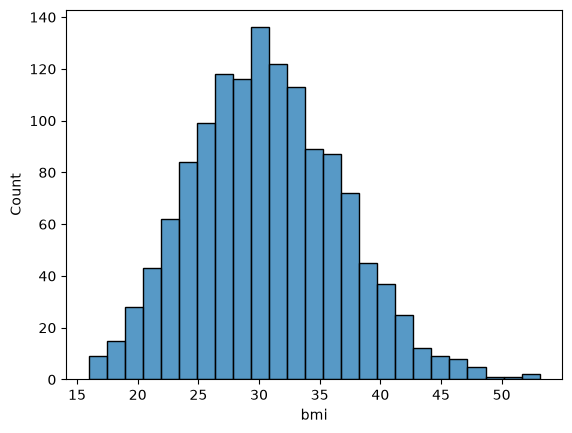

In [45]:
sns.histplot(df['bmi'])

In [46]:
df_clean['bmi_category']=pd.cut(
    df_clean['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['UnderWeigth','Normal','Overweith','Obese']
)

In [47]:
df_clean.head()

,age,is_Gender,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweith
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweith


In [48]:
df_clean['bmi_category'].value_counts()

bmi_category
Obese          706
Overweith      386
Normal         221
UnderWeigth     24
Name: count, dtype: int64

In [49]:
# change the bmi_category columns
# <-- true = 1
# <-- false = 0
df_clean=pd.get_dummies(df_clean, columns=['bmi_category'],drop_first=True)  

In [50]:
bmi = [
    'bmi_category_Normal',
    'bmi_category_Overweith',
    'bmi_category_Obese'
]

df_clean[bmi] = df_clean[bmi].astype(int)


In [51]:
df_clean.columns

Index(['age', 'is_Gender', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweith', 'bmi_category_Obese'],
      dtype='str')

# standerd scaller

In [52]:
from sklearn.preprocessing import StandardScaler

In [53]:

cols=['age','bmi','children']
scaler=StandardScaler()

df_clean[cols]=scaler.fit_transform(df_clean[cols])

In [54]:
# this data after trian  model data
df_clean

,age,is_Gender,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweith,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,1,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,1,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,1,0,1,0


In [57]:
df_clean.columns

Index(['age', 'is_Gender', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweith', 'bmi_category_Obese'],
      dtype='str')

In [61]:
final_df =df_clean[['age','is_Gender','bmi','children','is_smoker','charges','region_southeast','bmi_category_Obese']]
final_df

,age,is_Gender,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0


In [55]:
# this real data 
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,1,southwest,16884.92
1,18,male,33.770,1,0,southeast,1725.55
2,28,male,33.000,3,0,southeast,4449.46
3,33,male,22.705,0,0,northwest,21984.47
4,32,male,28.880,0,0,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,0,northwest,10600.55
1334,18,female,31.920,0,0,northeast,2205.98
1335,18,female,36.850,0,0,southeast,1629.83
1336,21,female,25.800,0,0,southwest,2007.94
